In [2]:
# ============================================
# LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set(style="whitegrid")

En esta celda se importan las principales librerías necesarias para el desarrollo del análisis de datos y los modelos de Machine Learning. Se utilizan Pandas y NumPy para la manipulación y el cálculo numérico de los datos, Seaborn y Matplotlib para la visualización gráfica, y Scikit-learn para la división del dataset, el entrenamiento de modelos de regresión lineal y logística, el preprocesamiento de variables y la evaluación del desempeño mediante diferentes métricas. Finalmente, se configura un estilo visual global para mejorar la legibilidad de los gráficos.

In [4]:
# ============================================
# CARGA DE DATOS
# ============================================

df = sns.load_dataset("penguins").copy()

print("Dimensiones:", df.shape)

print("\nTipos de datos:")
print(df.dtypes)

df.head()

Dimensiones: (344, 7)

Tipos de datos:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


En esta celda se carga el dataset público de Palmer Penguins utilizando la función load_dataset de Seaborn. Posteriormente se imprime la dimensión del conjunto de datos para conocer el número de registros y variables disponibles. Finalmente, se visualizan las primeras filas del DataFrame con el fin de realizar una inspección inicial de los datos antes de comenzar el análisis exploratorio.

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


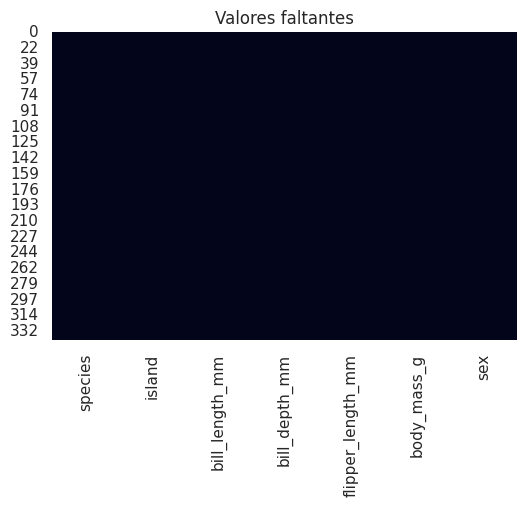

Nueva dimensión: (333, 7)


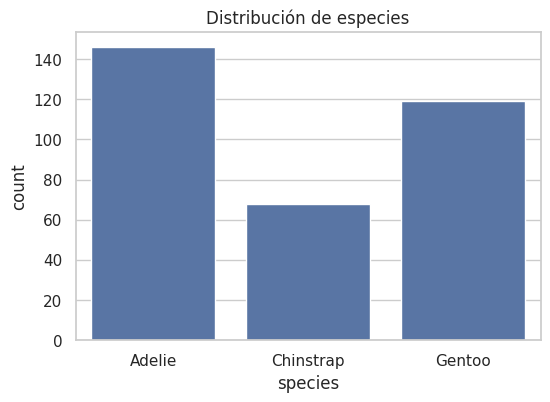

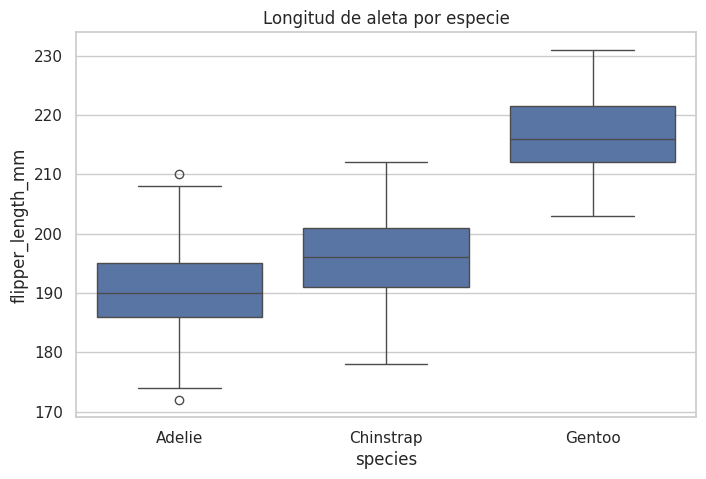

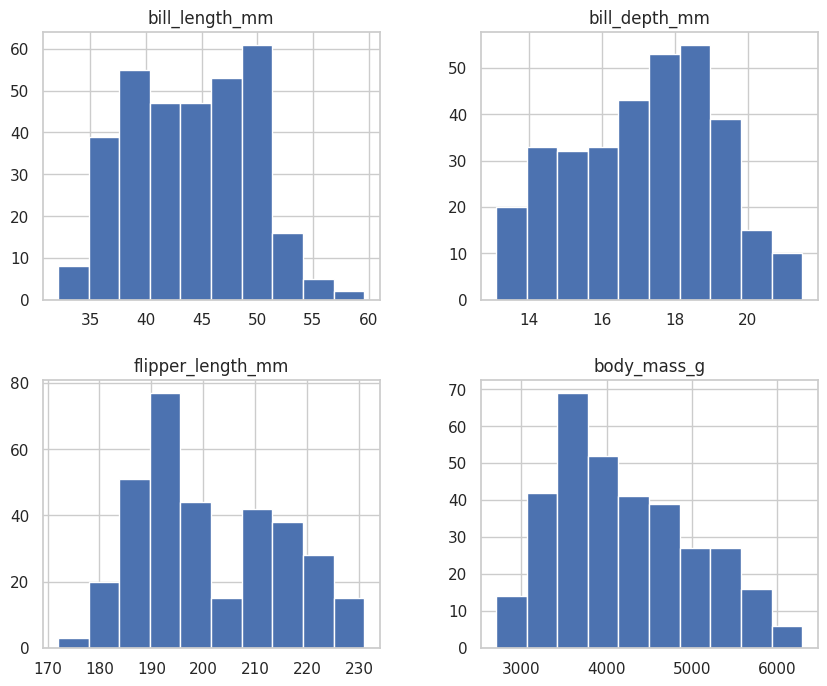

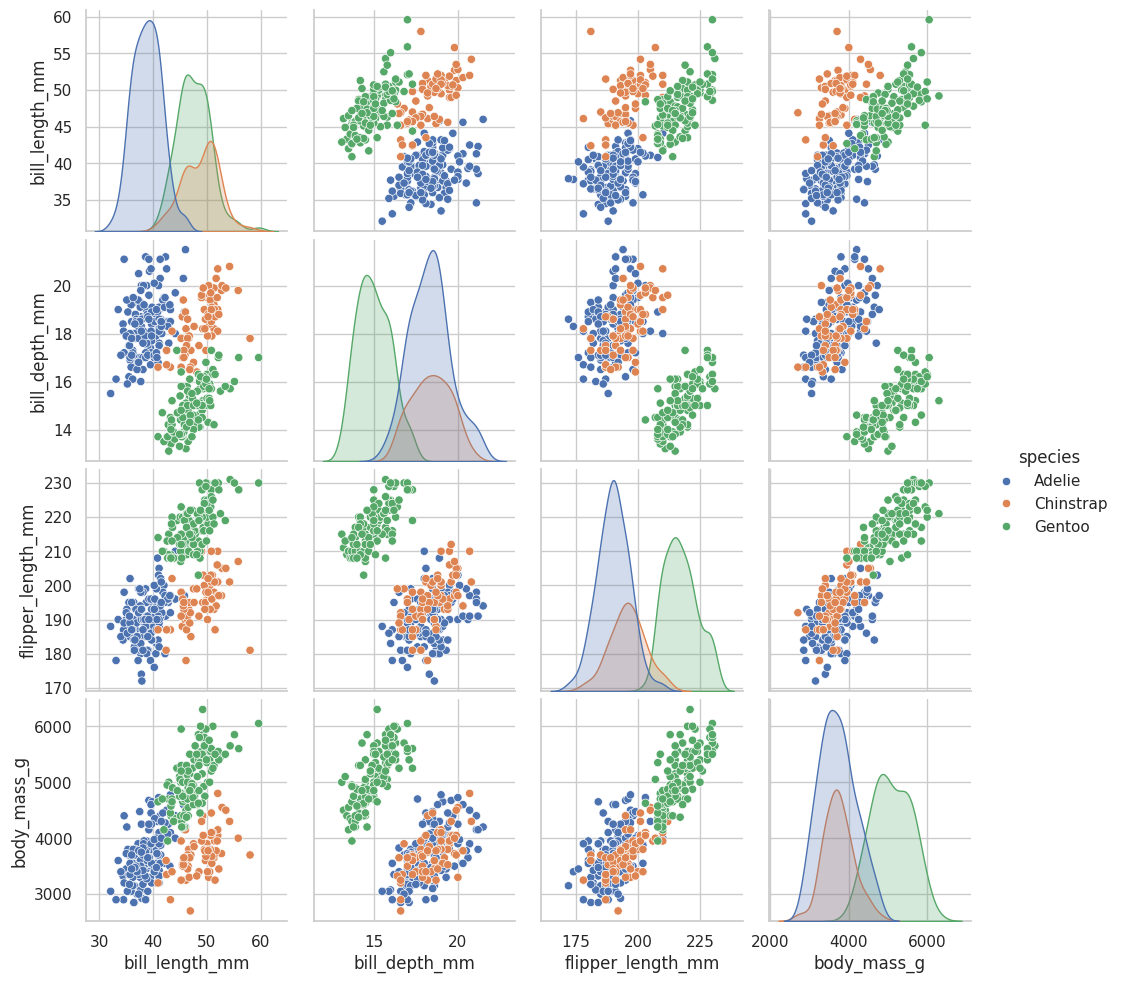

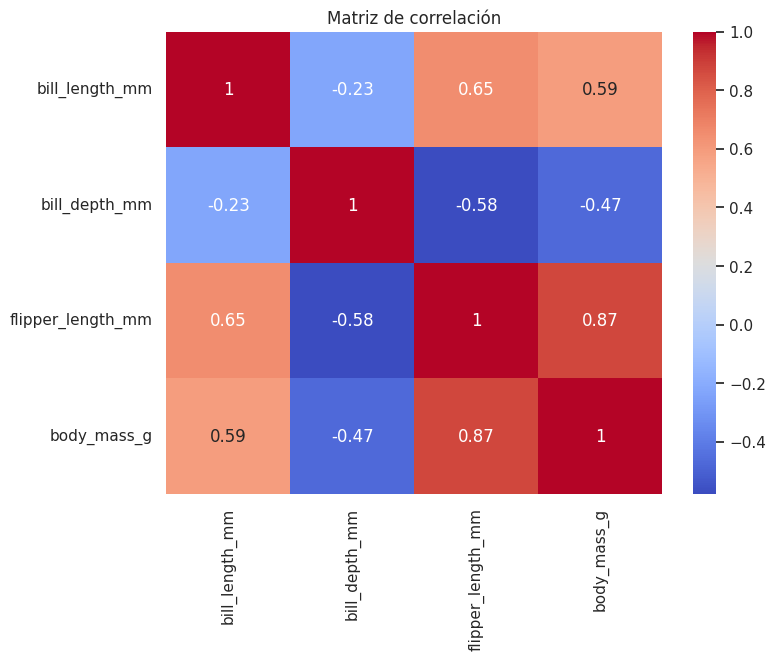

In [14]:
# ============================================
# EDA
# ============================================

# Información general
df.info()

# Estadísticas descriptivas
df.describe()

# Valores faltantes
print(df.isnull().sum())

plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Valores faltantes")
plt.show()

# Justificación: eliminamos NA porque son pocos registros
df = df.dropna()

print("Nueva dimensión:", df.shape)

# Distribución de especies
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="species")
plt.title("Distribución de especies")
plt.show()

# Boxplots por especie (muy importante en este dataset)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="species", y="flipper_length_mm")
plt.title("Longitud de aleta por especie")
plt.show()

# Histogramas variables numéricas
df.hist(figsize=(10,8))
plt.show()

# Pairplot (clave para este dataset)
sns.pairplot(df, hue="species")
plt.show()

# Matriz de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

En esta celda se realiza el Análisis Exploratorio de Datos (EDA) del dataset de los pingüinos. Primero se inspecciona la estructura del conjunto de datos, los tipos de variables y los valores faltantes. Posteriormente se eliminan los registros incompletos debido a su baja proporción. Se analizan las distribuciones de las especies, así como la relación entre variables numéricas mediante histogramas, boxplots y gráficos de dispersión. Finalmente, se construye una matriz de correlación y un pairplot para identificar patrones, relaciones lineales y la separabilidad entre clases, lo cual es fundamental antes de aplicar modelos de Machine Learning.

In [9]:
print(df[["flipper_length_mm","body_mass_g"]].corr())

                   flipper_length_mm  body_mass_g
flipper_length_mm           1.000000     0.872979
body_mass_g                 0.872979     1.000000


Estas 2 variables tienen una correlación alta, por lo cual serán objeto de estudio para nuestra regresión.

Variable independiente (feature) → longitud de aleta

Variable dependiente (target) → peso corporal

MSE: 129886.71972544755
R2: 0.7938115564401114
Coeficiente: 50.41798199462178
Intercepto: -5919.258741821233


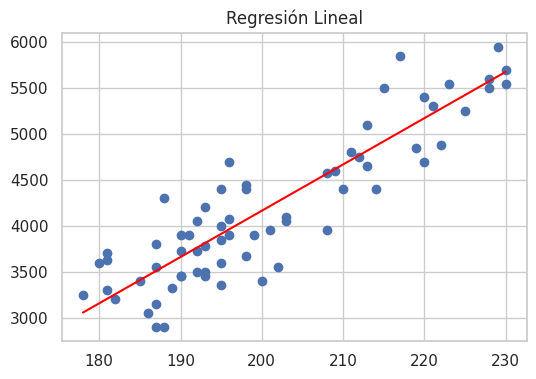

In [10]:
# ============================================
# REGRESIÓN LINEAL
# ============================================

# Objetivo: predecir el peso corporal usando longitud de aleta

X = df[["flipper_length_mm"]]
y = df["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

pred = modelo_lineal.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

# Interpretación del modelo
print("Coeficiente:", modelo_lineal.coef_[0])
print("Intercepto:", modelo_lineal.intercept_)

# Gráfico
idx = X_test.squeeze().argsort()

plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test)
plt.plot(
    X_test.squeeze().iloc[idx],
    pred[idx],
    color="red"
)
plt.title("Regresión Lineal")
plt.show()

En esta celda se implementa un modelo de regresión lineal simple con el objetivo de predecir el peso corporal del pingüino a partir de la longitud de su aleta. Primero se separan las variables predictoras y la variable objetivo, y posteriormente se dividen los datos en conjuntos de entrenamiento y prueba. El modelo se entrena utilizando LinearRegression y se evalúa mediante métricas como el Error Cuadrático Medio (MSE) y el coeficiente de determinación R². Finalmente, se interpretan los coeficientes del modelo y se visualiza gráficamente la relación entre los valores reales y la línea de regresión estimada.

Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



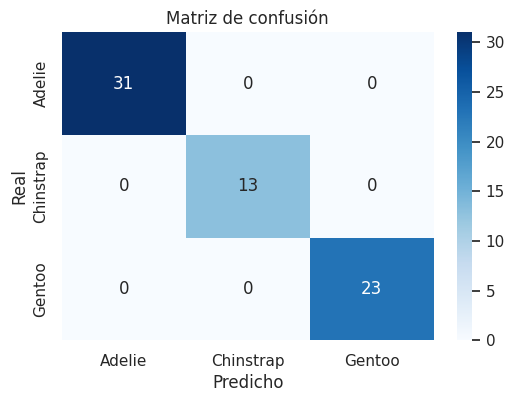

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Adelie,-2.595671,1.493387,-0.401426,0.329802
Chinstrap,2.231991,0.213990,-0.694147,-1.478937
Gentoo,0.363680,-1.707377,1.095573,1.149135


In [12]:
# ============================================
# REGRESIÓN LOGÍSTICA MULTICLASE
# ============================================

# Objetivo: clasificar especies

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features]
y = df["species"]

# Encoding
le = LabelEncoder()
y = le.fit_transform(y)

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

pred = modelo_log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Matriz de confusión")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

pd.DataFrame(
    modelo_log.coef_,
    columns=features,
    index=le.classes_
)


En esta celda se implementa un modelo de Regresión Logística Multiclase con el objetivo de clasificar la especie de los pingüinos a partir de variables morfológicas como la longitud y profundidad del pico, la longitud de la aleta y el peso corporal. Primero se codifica la variable objetivo mediante LabelEncoder y se normalizan las variables predictoras utilizando StandardScaler. Posteriormente se dividen los datos en conjuntos de entrenamiento y prueba, se entrena el modelo y se evalúa su desempeño mediante métricas como Accuracy, Precision, Recall y F1-score. Finalmente, se construye y visualiza la matriz de confusión para analizar los aciertos y errores de clasificación entre especies.

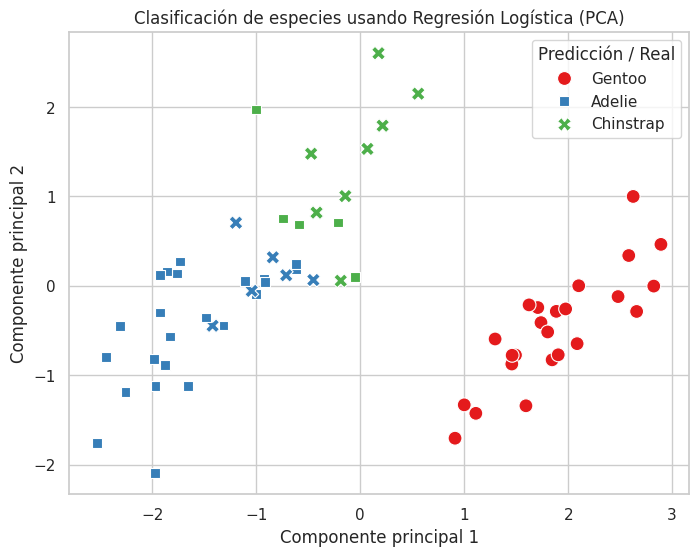

In [13]:
from sklearn.decomposition import PCA

# Reducimos a 2 dimensiones solo para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Split otra vez pero sobre los datos reducidos
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenamos modelo sobre PCA
modelo_log_pca = LogisticRegression(max_iter=1000)
modelo_log_pca.fit(X_train_pca, y_train)

pred_pca = modelo_log_pca.predict(X_test_pca)

# Gráfica de clasificación
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_test_pca[:,0],
    y=X_test_pca[:,1],
    hue=le.inverse_transform(pred_pca),
    style=le.inverse_transform(y_test),
    palette="Set1",
    s=100
)

plt.title("Clasificación de especies usando Regresión Logística (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Predicción / Real")
plt.show()